# Phase III — Kernel Methods (Support Vector Machines)
## Bank Marketing Dataset — ML Lab Project 2026

**Authors:** Arman Bazarchi, Ines Maria Madeira Prates

---

**Prerequisites:** Run `preprocessing.ipynb` first to generate the processed data in `data/`.

This notebook trains Support Vector Machines with three kernels (linear, polynomial, RBF) and
tunes them with grid search. Our central practical challenge is **scalability**: kernel SVMs cost
roughly O(n^2)-O(n^3), so a full grid search on all ~33k training rows is impractical. We therefore
tune on a stratified subsample but evaluate every final model on the FULL test set, for a fair
comparison with the Phase II linear models.

### Outline
1. Load Processed Data & Prepare Features
2. Baseline & Subsampling Strategy
3. SVM Kernels — Default Comparison (linear / polynomial / RBF)
4. Hyperparameter Tuning — Grid Search per Kernel
5. Final Evaluation on the Test Set & Model Comparison
6. Linear-SVM Coefficients — Feature View
7. Summary & Discussion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix,
                             roc_curve, precision_recall_curve, classification_report)

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
## 1. Load Processed Data & Prepare Features

We reuse the exact feature sets from Phase II so results are directly comparable: drop the leaky
`duration`, one-hot encode the categorical strings, and take the same 80/20 stratified split.

In [2]:
X_scaled_df = pd.read_csv('data/X_scaled.csv')       # 15 standardized numeric features
cat_features = pd.read_csv('data/cat_features.csv')   # job, marital, month, day_of_week
y = pd.read_csv('data/y.csv')['y']

# Drop leaky 'duration' (known only after the call), one-hot the categoricals (drop_first avoids
# the dummy trap). SVMs, especially the RBF kernel are distance-based, so the standardized
# numeric features + 0/1 dummies are exactly the right input scale.
X_num = X_scaled_df.drop(columns=['duration'])
X_cat = pd.get_dummies(cat_features, drop_first=True).astype(int)
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Full design matrix: {X.shape}")
print(f"Train: {X_train.shape[0]} samples ({y_train.mean()*100:.2f}% positive)")
print(f"Test:  {X_test.shape[0]} samples ({y_test.mean()*100:.2f}% positive)")

Full design matrix: (41188, 41)
Train: 32950 samples (11.27% positive)
Test:  8238 samples (11.26% positive)


---
## 2. Baseline & Subsampling Strategy

In [3]:
# baseline: a stratified dummy classifier that ignores the features entirely.
# Any real model must clearly beat this to be useful.
dummy = DummyClassifier(strategy='stratified', random_state=42).fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_scores = dummy.predict_proba(X_test)[:, 1]

print("Baseline (stratified dummy):")
print(f"  Accuracy: {accuracy_score(y_test, dummy_pred):.4f}")
print(f"  F1 (Yes): {f1_score(y_test, dummy_pred):.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_test, dummy_scores):.4f}")
print(f"  AUPR:     {average_precision_score(y_test, dummy_scores):.4f}")

# The dummy scores ROC-AUC = 0.505 (= chance) and AUPR = 0.114 (= the positive rate), confirming
# it has no predictive power. Its 80% accuracy is purely an imbalance artifact, exactly why
# accuracy is the wrong metric here. Every real model below must pass ROC-AUC 0.5 / AUPR 0.11.

Baseline (stratified dummy):
  Accuracy: 0.8037
  F1 (Yes): 0.1207
  ROC-AUC:  0.5051
  AUPR:     0.1137


In [4]:
# Kernel SVM training is ~O(n^2)-O(n^3) in the number of samples, so fitting (and
# especially grid-searching) on all 32,950 training rows is impractical. So we tune on a stratified
# subsample of 12k, then evaluate the chosen models on the FULL test set (8,238 rows) so the reported
# numbers stay comparable with Phase II.
N_SUB = 12000
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=N_SUB, stratify=y_train, random_state=42
)
print(f"SVM training subsample: {X_sub.shape[0]} samples ({y_sub.mean()*100:.2f}% positive)")
print(f"Final evaluation still uses the full test set: {X_test.shape[0]} samples")

SVM training subsample: 12000 samples (11.27% positive)
Final evaluation still uses the full test set: 8238 samples


---
## 3. SVM Kernels — Default Comparison

Before tuning, we fit each kernel once with default settings (`class_weight='balanced'`,
`gamma='scale'`) on the subsample, to see which kernels look promising and how training cost differs.
We score with `decision_function` (rank-based), so ROC-AUC / AUPR need no probability calibration.

In [5]:
def eval_svm(name, model, Xte, yte, fit_time=None):
    scores = model.decision_function(Xte)
    pred = model.predict(Xte)
    return {
        'model': name,
        'accuracy': accuracy_score(yte, pred),
        'f1': f1_score(yte, pred),
        'roc_auc': roc_auc_score(yte, scores),
        'aupr': average_precision_score(yte, scores),
        'fit_time_s': fit_time,
    }

default_rows = []
for name, kernel in [('Linear', 'linear'), ('Polynomial', 'poly'), ('RBF', 'rbf')]:
    clf = SVC(kernel=kernel, class_weight='balanced', gamma='scale', random_state=42)
    t0 = time.perf_counter()
    clf.fit(X_sub, y_sub)
    ft = time.perf_counter() - t0
    default_rows.append(eval_svm(name, clf, X_test, y_test, ft))

default_df = pd.DataFrame(default_rows).set_index('model')
print("Default SVM kernels (trained on subsample, evaluated on full test set):")
print(default_df.round(4).to_string())

# With defaults, all three kernels land in a tight band (ROC-AUC 0.77-0.78, AUPR 0.37-0.40) and
# all clearly beat the baseline. RBF has the best ROC-AUC (0.784) and Polynomial the best AUPR (0.40).
# This narrow spread is the first hint that the decision boundary is close to linear, since
# non-linear kernels do not advance much.
#
# Training cost: on 12,000 rows poly/RBF fit in ~2s, but SVC(kernel='linear') via libsvm is much
# slower (~11s) -- a libsvm quirk (LinearSVC) would be far faster, but we keep it to maintain same algorithm.

Default SVM kernels (trained on subsample, evaluated on full test set):
            accuracy      f1  roc_auc    aupr  fit_time_s
model                                                    
Linear        0.8372  0.4621   0.7798  0.3744     11.1394
Polynomial    0.8480  0.4686   0.7747  0.4006      2.1570
RBF           0.8498  0.4882   0.7835  0.3902      2.1528


---
## 4. Hyperparameter Tuning — Grid Search per Kernel

We grid-search each kernel with 3-fold stratified CV on the subsample, optimizing **ROC-AUC**
(threshold-independent and robust to the 11% imbalance). Key hyperparameters:
- **Linear:** `C` (margin softness).
- **Polynomial:** `C`, `degree`, `gamma`.
- **RBF:** `C`, `gamma` (kernel width).

In [6]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grids = {
    'Linear': (SVC(kernel='linear', class_weight='balanced', random_state=42),
               {'C': [0.01, 0.1, 1, 10]}),
    'Polynomial': (SVC(kernel='poly', class_weight='balanced', gamma='scale', random_state=42),
                   {'C': [0.1, 1, 10], 'degree': [2, 3]}),
    'RBF': (SVC(kernel='rbf', class_weight='balanced', random_state=42),
            {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1]}),
}

tuned = {}
tuned_rows = []
for name, (estimator, param_grid) in grids.items():
    gs = GridSearchCV(estimator, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
    t0 = time.perf_counter()
    gs.fit(X_sub, y_sub)
    ft = time.perf_counter() - t0
    tuned[name] = gs.best_estimator_
    row = eval_svm(name, gs.best_estimator_, X_test, y_test, ft)
    row['best_params'] = gs.best_params_
    row['cv_roc_auc'] = gs.best_score_
    tuned_rows.append(row)
    print(f"{name:>11s}: best params {gs.best_params_}, CV ROC-AUC={gs.best_score_:.4f}, fit={ft:.1f}s")

tuned_df = pd.DataFrame(tuned_rows).set_index('model')

# The tuned kernels reach CV ROC-AUC ~0.76-0.78: RBF and Polynomial (~0.778) beats Linear (0.762).
#
#   - Linear     -> C=0.1
#   - Polynomial -> degree=2 (not 3) with C=1   (a low-order curve)
#   - RBF        -> C=1 with gamma=0.01         (a WIDE kernel, smooth, near-linear boundary)
# Best poly is only degree 2 and best RBF is a wide/smooth one, then data does not reward sharp
# non-linear boundaries, the structure is close to linearly separable in this feature space.


     Linear: best params {'C': 0.1}, CV ROC-AUC=0.7625, fit=55.2s


 Polynomial: best params {'C': 1, 'degree': 2}, CV ROC-AUC=0.7779, fit=8.3s


        RBF: best params {'C': 1, 'gamma': 0.01}, CV ROC-AUC=0.7784, fit=14.8s


---
## 5. Final Evaluation on the Test Set & Model Comparison

In [7]:
compare = tuned_df[['accuracy', 'f1', 'roc_auc', 'aupr', 'fit_time_s']].copy()
compare.loc['Baseline (dummy)'] = [accuracy_score(y_test, dummy_pred), f1_score(y_test, dummy_pred),
                                   roc_auc_score(y_test, dummy_scores),
                                   average_precision_score(y_test, dummy_scores), np.nan]
compare = compare.sort_values('roc_auc', ascending=False)
print("Tuned SVMs vs baseline (full test set):")
print(compare.round(4).to_string())
print("\nBest tuned hyperparameters:")
for r in tuned_rows:
    print(f"  {r['model']:>11s}: {r['best_params']}")

# On the full test set the tuned kernels are nearly tied (ROC-AUC 0.784-0.793, AUPR 0.38-0.44) and
# all massively beat the baseline. RBF is best on ROC-AUC (0.793), Polynomial is
# best on AUPR (0.436) and essentially tied on ROC-AUC (0.788), Linear differs slightly (0.784/0.384).
# (The "winner" flips between RBF and Poly across subsample sizes, so they are within noise.)
#
# Tuning for ROC-AUC specifically improved the results over the Section-3 defaults (e.g. RBF AUPR
# 0.390 -> 0.431) at a small cost to F1/accuracy, this shows the importance of choosing a 
# tuning metric that matches the goal.
#
# Versus Phase II logistic (ROC-AUC ~0.797, AUPR ~0.428): the SVMs essentially MATCH it, RBF/Poly
# AUPR (0.43-0.44) slightly exceed it, despite training on 12k rows vs logistic's 33k. The
# non-linear kernels do not differ much from the linear model, confirming a near-linear boundary.

Tuned SVMs vs baseline (full test set):
                  accuracy      f1  roc_auc    aupr  fit_time_s
model                                                          
RBF                 0.8390  0.4704   0.7928  0.4311     14.8129
Polynomial          0.8464  0.4813   0.7877  0.4360      8.3030
Linear              0.8384  0.4635   0.7839  0.3835     55.2362
Baseline (dummy)    0.8037  0.1207   0.5051  0.1137         NaN

Best tuned hyperparameters:
       Linear: {'C': 0.1}
   Polynomial: {'C': 1, 'degree': 2}
          RBF: {'C': 1, 'gamma': 0.01}


Best kernel by test ROC-AUC: RBF
              precision    recall  f1-score   support

          No       0.95      0.86      0.91      7310
         Yes       0.37      0.63      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.86      8238



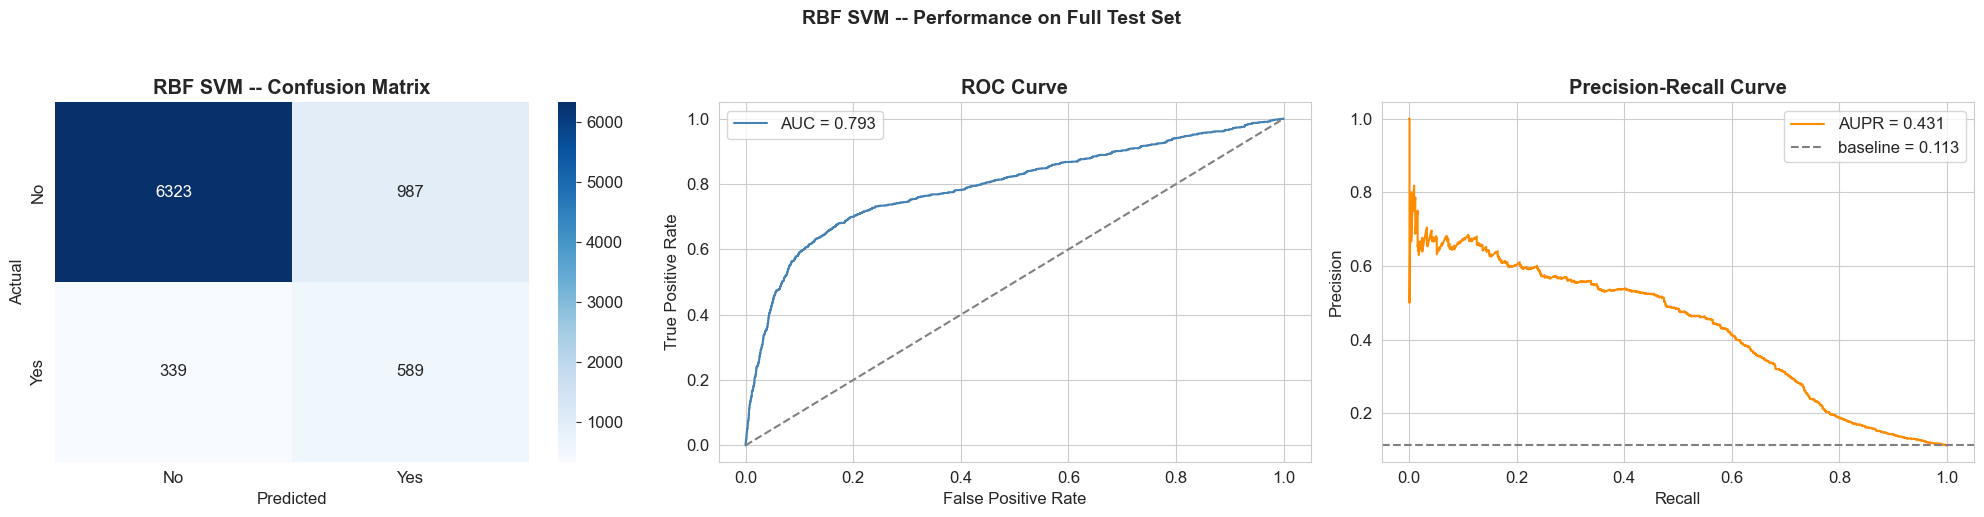

In [8]:
# Pick the best kernel by test ROC-AUC and inspect it in detail
best_name = compare.drop(index='Baseline (dummy)')['roc_auc'].idxmax()
best_model = tuned[best_name]
best_scores = best_model.decision_function(X_test)
best_pred = best_model.predict(X_test)

print(f"Best kernel by test ROC-AUC: {best_name}")
print("=" * 60)
print(classification_report(y_test, best_pred, target_names=['No', 'Yes']))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title(f'{best_name} SVM -- Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, best_scores)
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC = {roc_auc_score(y_test, best_scores):.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold'); axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, best_scores)
axes[2].plot(rec, prec, color='darkorange', label=f'AUPR = {average_precision_score(y_test, best_scores):.3f}')
axes[2].axhline(y=y_test.mean(), linestyle='--', color='gray', label=f'baseline = {y_test.mean():.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold'); axes[2].legend()

plt.suptitle(f'{best_name} SVM -- Performance on Full Test Set', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# RBF wins (ROC-AUC 0.793), though Polynomial is within noise. Its confusion matrix
# shows the familiar balanced-weight profile: good recall on subscribers (0.63) at low precision
# (0.37), catching most subscribers but still with many false positives.
# The ROC and PR curves sit well above chance / the 0.113 baseline but stable at the same
# ~0.79 ROC-AUC / ~0.43 AUPR that every model in this project hits, its a direct consequence of
# the heavy class overlap that we noticed in Phase I's 2D PCA projection.

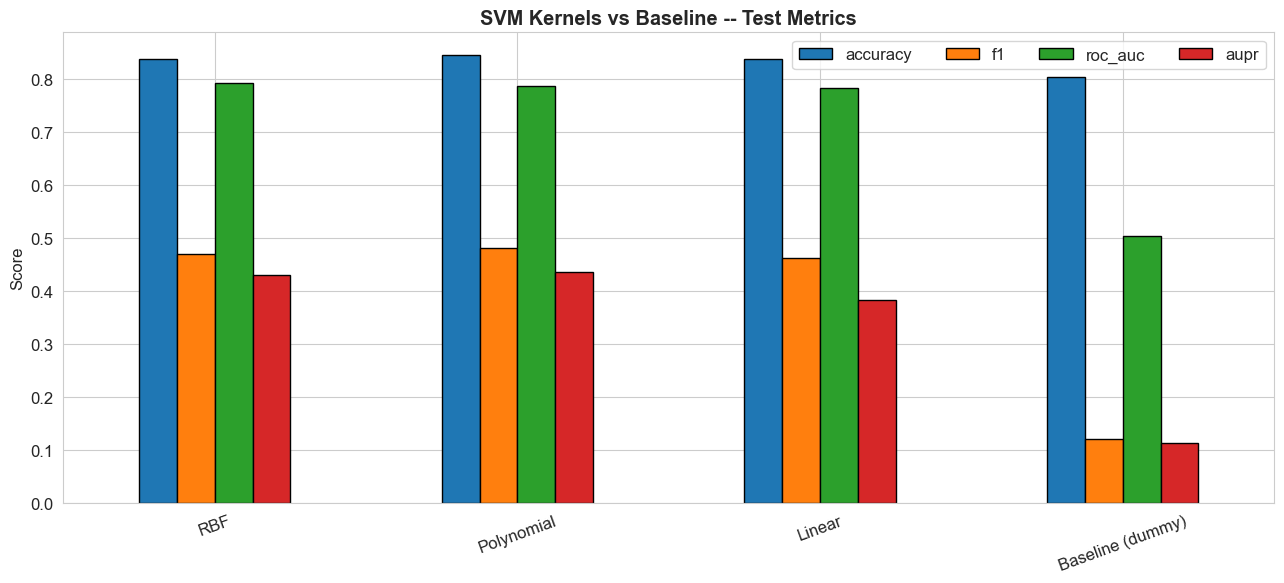

In [9]:
# Visual comparison of the tuned kernels + baseline across metrics
plot_df = compare[['accuracy', 'f1', 'roc_auc', 'aupr']]
ax = plot_df.plot(kind='bar', figsize=(13, 6), edgecolor='black')
ax.set_title('SVM Kernels vs Baseline -- Test Metrics', fontweight='bold')
ax.set_ylabel('Score'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='upper right', ncol=4)
plt.tight_layout()
plt.show()

---
## 6. Linear-SVM Coefficients — Feature View

The RBF/poly kernels are not directly interpretable (no per-feature weights), but the **linear**
SVM is — like logistic regression, its `coef_` gives a per-feature contribution. We inspect it to
check the drivers agree with Phase I / II.

Linear-SVM coefficients (top 15 by |weight|):
emp.var.rate      -2.595
euribor3m          1.591
month_jun         -1.510
month_may         -1.224
month_nov         -1.223
cons.price.idx     1.027
month_sep         -1.027
month_oct         -1.020
month_dec         -0.740
month_jul         -0.572
nr.employed       -0.452
month_aug          0.372
marital_unknown    0.261
month_mar          0.244
cons.conf.idx     -0.076


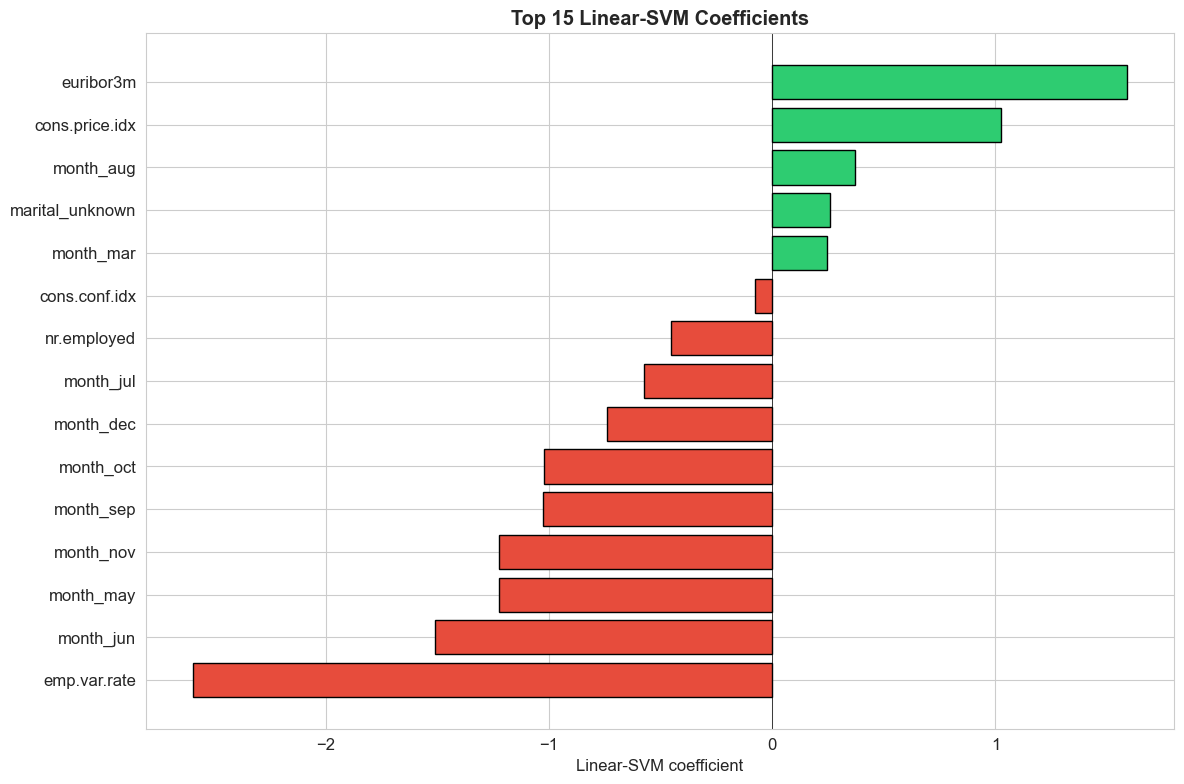

In [16]:
lin_svm = tuned['Linear']
svm_coef = pd.Series(lin_svm.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)

print("Linear-SVM coefficients (top 15 by |weight|):")
print(svm_coef.head(15).round(3).to_string())

top = svm_coef.head(15).sort_values()
plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top.values]
plt.barh(range(len(top)), top.values, color=colors, edgecolor='black')
plt.yticks(range(len(top)), top.index)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.xlabel('Linear-SVM coefficient')
plt.title('Top 15 Linear-SVM Coefficients', fontweight='bold')
plt.tight_layout()
plt.show()

# The tuned linear SVM (C=0.1, a moderate strength) is dominated by the calendar months
# (jun/may/nov/sep/oct negative, mar/aug positive) and the economy block. Here the economic features,
# emp.var.rate is strongly negative (-2.60) and nr.employed also negative (-0.45), but
# euribor3m flips POSITIVE (+1.59), cons.price.idx positive (+1.03). This is again the same
# multicollinearity instability we pointed in Phase II so the within-macro signs are not reliable.
# The dominant drivers (economy + campaign timing) still match EDA and Phase I, so the kernels lean
# on the same signal.

In [17]:
# ============================================================================
# FEATURE-EXTRACTION EXPERIMENT: can engineered features reduce the class overlap?
# ----------------------------------------------------------------------------
# The linear/kernel models only capture MAIN effects. We add a few features that encode
# information they cannot otherwise express, chosen from the drivers interpreted up to now:
#   - interaction terms among the top campaign/economy signals (genuinely new, non-linear info)
#   - one PCA "economic composite" extracted from the collinear euribor/emp.var/nr.employed/price,
#     classic feature EXTRACTION that uses the shared economic signal.
# Then we re-run the SAME tuned kernels and compare to the original feature set.
from sklearn.decomposition import PCA

X_eng = X.copy()
X_eng['poutcome_x_previous'] = X['poutcome'] * X['previous']            # prior-success strength
X_eng['euribor_x_campaign']  = X['euribor3m'] * X['campaign']           # economy x contact effort
X_eng['empvar_x_contact']    = X['emp.var.rate'] * X['contact']         # economy x channel
X_eng['conf_x_price']        = X['cons.conf.idx'] * X['cons.price.idx'] # sentiment x prices

macro_cols = ['euribor3m', 'emp.var.rate', 'nr.employed', 'cons.price.idx']
X_eng['macro_pc1'] = PCA(n_components=1, random_state=42).fit_transform(X[macro_cols])[:, 0]

# Re-standardize the new columns so the SVM penalty treats them on the same scale
new_cols = ['poutcome_x_previous', 'euribor_x_campaign', 'empvar_x_contact', 'conf_x_price', 'macro_pc1']
X_eng[new_cols] = (X_eng[new_cols] - X_eng[new_cols].mean()) / X_eng[new_cols].std()
print(f"Engineered matrix: {X_eng.shape} (added {len(new_cols)} features: {new_cols})")

# Same split (identical random_state => identical test rows) and same subsample size
Xtr_e, Xte_e, ytr_e, yte_e = train_test_split(X_eng, y, test_size=0.2, stratify=y, random_state=42)
Xsub_e, _, ysub_e, _ = train_test_split(Xtr_e, ytr_e, train_size=N_SUB, stratify=ytr_e, random_state=42)

# Same methods: tune linear/poly/RBF with the SAME grids + CV on the engineered subsample
eng_rows = []
for name, (estimator, param_grid) in grids.items():
    gs = GridSearchCV(estimator, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
    gs.fit(Xsub_e, ysub_e)
    eng_rows.append(eval_svm(name, gs.best_estimator_, Xte_e, yte_e))
eng_df = pd.DataFrame(eng_rows).set_index('model')[['roc_auc', 'aupr', 'f1']]

# Side-by-side vs the original (no engineered features) tuned results
orig = tuned_df[['roc_auc', 'aupr', 'f1']]
comp_fe = orig.join(eng_df, lsuffix='_orig', rsuffix='_eng')
for m in ['roc_auc', 'aupr', 'f1']:
    comp_fe[f'{m}_delta'] = (comp_fe[f'{m}_eng'] - comp_fe[f'{m}_orig'])
print("\nOriginal vs engineered features (tuned SVMs, full test set):")
print(comp_fe[['roc_auc_orig', 'roc_auc_eng', 'roc_auc_delta',
               'aupr_orig', 'aupr_eng', 'aupr_delta']].round(4).to_string())

# RESULT: engineered features give a small but consistent ROC-AUC lift across all kernels
# (+0.004 to +0.006), RBF reaches 0.797, the best in this notebook and same with the Phase II
# logistic.
#
# The most important change is the LINEAR model's AUPR: +0.044 (0.384 -> 0.427), while Poly/RBF AUPR
# barely move. This is exactly what theory predicts: the interaction terms hand the LINEAR
# model explicit non-linear signal it could not form on its own, so it catches up, the kernels
# already captured those interactions implicitly, so explicit features add little for them.
#
# feature engineering helps, but not much, and mainly by letting the linear model
# express interactions the kernels already had. It does NOT break the ~0.79 ROC-AUC / ~0.43 AUPR


Engineered matrix: (41188, 46) (added 5 features: ['poutcome_x_previous', 'euribor_x_campaign', 'empvar_x_contact', 'conf_x_price', 'macro_pc1'])

Original vs engineered features (tuned SVMs, full test set):
            roc_auc_orig  roc_auc_eng  roc_auc_delta  aupr_orig  aupr_eng  aupr_delta
model                                                                                
Linear            0.7839       0.7895         0.0056     0.3835    0.4272      0.0437
Polynomial        0.7877       0.7912         0.0035     0.4360    0.4361      0.0001
RBF               0.7928       0.7973         0.0045     0.4311    0.4315      0.0004


---
## 7. Summary & Discussion

### Key Findings — Phase III

**Setup:**
- Same features and split as Phase II. Kernel SVMs are O(n²)–O(n³), so we tuned on a stratified
  **12,000-row subsample** (3-fold CV, grid search on **ROC-AUC**, `class_weight='balanced'`) and
  evaluated every final model on the **full 8,238-row test set** for comparability.

**Kernel comparison:**
- All three kernels beat the baseline massively (ROC-AUC 0.505 → ~0.79) and land in a **tight band**
  (test ROC-AUC 0.784–0.793, AUPR 0.38–0.44).
- **RBF** is marginally best on ROC-AUC (0.793), while Polynomial (deg 2) is best on AUPR (0.436) and
  essentially tied on ROC-AUC (0.788); **Linear** differs slightly (0.784 / 0.384). The "winner"
  flips between RBF and Poly across different subsample sizes — they are within noise.
- Tuning favoured **smooth / low-complexity** settings (Linear `C=0.1`, Poly `degree=2`, RBF wide
  `gamma=0.01`) — the data does not reward sharp non-linear boundaries.


- The kernels essentially match the Phase II logistic model (ROC-AUC ~0.797, AUPR ~0.428),
  RBF/Poly AUPR slightly exceed it — while training on 12k rows vs logistic's 33k.
- Near-identical performance across linear and non-linear kernels means the decision boundary is
  near-linear in this feature space.
- Every model stabilizes at the same **~0.79 ROC-AUC / ~0.43 AUPR ceiling**, reflecting the heavy
  class overlap diagnosed in Phase I.
- Tuning on ROC-AUC raised the ranking metrics over the defaults at a small F1/accuracy cost —
  a reminder to align the tuning metric with the scope.

**Dataset challenges:**
- **Scalability:** kernel-SVM cost forced subsampling for tuning — the linear grid alone took ~55s
  on 12k and would be far worse on 33k. Scalable alternative can be `LinearSVC`,
  but we dont change it to keep using same algorithm.
- **Class imbalance + class overlap** control the achievable precision (low precision at high recall).

**For later phases:**
- Since non-linear kernels also do not improve results much, from linear models,
  the main remaining hope for a real jump is **ensemble methods** that capture feature
  interactions differently (Phase IV: Random Forest, boosting) — and which also handle
  the mixed/collinear features more naturally.

